# Training GCN Model (reference)

## Import Lib and define paths

In [1]:
# === Path Variables ===# Healthy

import os  # For handling file paths and directories
import pandas as pd  # For working with tabular data using DataFrames
import matplotlib.pyplot as plt  # For generating plots
import seaborn as sns  # For enhanced visualizations of heatmaps
import zipfile  # For reading compressed files without extracting them
import re  # For extracting numerical IDs using regular expressions

import torch
import random
import numpy as np

import os
import pandas as pd
import numpy as np

import networkx as nx  # For graph-level metrics


BASE_DIR = "../../../input_columns_1mm/input_columns"
QSM_DIR = "../../../QSM"
SUBJECT_IDS_CSV = "../../age_prediction_on_columns_analyses/subject_ids.csv"
AGE_CSV = "../../age_prediction_on_columns_analyses/ages.csv"
subject_df = pd.read_csv(SUBJECT_IDS_CSV, header=None)
age_df = pd.read_csv(AGE_CSV, header=None)
metadata_path = "../../../AD_DECODE_data3.xlsx"
df_metadata = pd.read_excel(metadata_path)


## Delete the abnormal QSM subjects

In [2]:
# The abnormal QSM subjects list
abnormal_qsm_subjects = [2765, 2320, 3343, 3350, 1412
                         , 1619, 3866, 2231]
# Delete the abnormal QSM subjects from the subject_df
subject_df = subject_df[~subject_df[0].isin(abnormal_qsm_subjects)]

In [3]:
# === Set seed for reproducibility ===
def seed_everything(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

seed_everything(42)

#Load columns

# Base directory where subject folders (e.g., S00775_columns_1mm) are stored


In [4]:
# List of hemispheres
HEMIS = ["lh", "rh"]


In [5]:
# List of cortical regions (based on the parcellation used)
REGION_NAMES = ['bankssts',
'caudalanteriorcingulate',
'caudalmiddlefrontal',
'cuneus',
'entorhinal',
'fusiform',
'inferiorparietal',
'inferiortemporal',
'isthmuscingulate',
'lateraloccipital',
'lateralorbitofrontal',
'lingual',
'medialorbitofrontal',
'middletemporal',
'parahippocampal',
'paracentral',
'parsopercularis',
'parsorbitalis',
'parstriangularis',
'pericalcarine',
'postcentral',
'posteriorcingulate',
'precentral',
'precuneus',
'rostralanteriorcingulate',
'rostralmiddlefrontal',
'superiorfrontal',
'superiorparietal',
'superiortemporal',
'supramarginal',
'frontalpole',
'temporalpole',
'transversetemporal',
'insula'
]
region_keys = [f"{hemi}_{region}" for hemi in HEMIS for region in REGION_NAMES]

In [6]:
############################## METADATA ##############################

print("ADDECODE METADATA\n")

ADDECODE METADATA



In [7]:
# Zero-pad subject IDs to 5-digit strings
subject_ids = subject_df[0].astype(str).apply(lambda x: x.zfill(5)).tolist()

In [8]:
# Standardize MRI_Exam IDs
df_metadata["MRI_Exam_fixed"] = (
    df_metadata["MRI_Exam"]
    .fillna(0)
    .astype(int)
    .astype(str)
    .str.zfill(5)
)



In [9]:
# Drop fully empty rows and rows missing MRI_Exam
df_metadata_cleaned = df_metadata.dropna(how="all")
df_metadata_cleaned = df_metadata_cleaned.dropna(subset=["MRI_Exam"])


In [10]:
# === Filter metadata to match only included subject IDs ===
df_matched = df_metadata_cleaned[df_metadata_cleaned["MRI_Exam_fixed"].isin(subject_ids)].copy()


In [11]:
# === Only keep valid IDs for reordering to avoid KeyError ===
valid_ids = [sid for sid in subject_ids if sid in df_matched["MRI_Exam_fixed"].values]


In [12]:
# === Reorder safely ===
df_matched = df_matched.set_index("MRI_Exam_fixed").loc[valid_ids].reset_index()


In [13]:
# === Clean 'Risk' column: treat NaNs and empty strings as 'NoRisk' ===
df_matched["Risk"] = (
    df_matched["Risk"]
    .fillna("NoRisk")                              # Replace NaNs
    .replace(r'^\s*$', "NoRisk", regex=True)       # Replace empty strings or whitespace
    .str.strip()                                   # Remove leading/trailing spaces
)


In [14]:
# === Filter only healthy or familial risk subjects ===
df_matched_filtered = df_matched[df_matched["Risk"].isin(["NoRisk", "Familial"])].copy()


In [15]:
# === Print summary ===
print("Remaining risk group distribution:")
print(df_matched_filtered["Risk"].value_counts())
print(f"\nSubjects before filtering: {len(df_matched)}")
print(f"Subjects after filtering:  {len(df_matched_filtered)}")


Remaining risk group distribution:
Risk
Familial    42
NoRisk      17
Name: count, dtype: int64

Subjects before filtering: 64
Subjects after filtering:  59


In [16]:
# Build age_dict from the healthy metadata dataframe
age_dict = dict(zip(df_matched_filtered["MRI_Exam_fixed"], df_matched_filtered["age"]))


In [17]:
# === Extract filtered subject IDs (already cleaned and filtered to NoRisk / Familial) ===
subject_ids = df_matched_filtered["MRI_Exam_fixed"].tolist()


In [18]:
# === Initialize final dictionary: subject_id -> region -> matrix ===
column_data = {}


In [19]:
# === Loop through filtered subjects ===
for subj_id in subject_ids:
    subj_dict = {}
    subj_dir = os.path.join(QSM_DIR, f"S{subj_id}", "QSM")  # Path to subject's folder

    for hemi in HEMIS:
        for region in REGION_NAMES:
            region_key = f"{hemi}_{region}"
            filename = f"S{subj_id}_{region_key}_QSM.csv"
            filepath = os.path.join(subj_dir, filename)

            if not os.path.exists(filepath):
                print(f"[WARNING] Missing: {filepath}")
                continue


            # Load CSV matrix as numpy array (float32)
            mat = pd.read_csv(filepath, header=None).values.astype(np.float32)
            subj_dict[region_key] = mat

    if len(subj_dict) > 0:
        column_data[subj_id] = subj_dict
    #else:
        #print(f"[INFO] Skipping subject {subj_id} (no valid regions found)")



In [20]:
# === OPTIONAL: Print region shapes for each subject ===
# for subj_id, regions in column_data.items():
#     print(f"\nSubject {subj_id}:")
#     for region_name, matrix in regions.items():
#         print(f"  {region_name} → {matrix.shape}")


In [21]:
# CONSTRUCT GRAPHS 

import os
import numpy as np
import pandas as pd
import torch
from torch_geometric.data import Data
from sklearn.neighbors import NearestNeighbors



In [22]:
# Get subject's data (dict: region → matrix)
subject_data = column_data[subj_id]

#Normalize
from sklearn.preprocessing import StandardScaler

# Concatenate all regions for one subject
x_np = np.vstack(list(subject_data.values()))  # shape [n_total_columns, 21]

# Z-score normalization across all features (columns)
scaler = StandardScaler()
x_np = scaler.fit_transform(x_np)


In [23]:
# === STEP 1: Build edge_index from K-Nearest Neighbors ===

def build_knn_edge_index(x_np, k=10):
    """
    Builds the edge_index for a graph using KNN based on node features.

    Args:
        x_np (np.ndarray): shape [n_nodes, n_features]
        k (int): number of neighbors per node

    Returns:
        edge_index (torch.LongTensor): shape [2, num_edges]
    """
    knn = NearestNeighbors(n_neighbors=k, metric="euclidean")
    knn.fit(x_np)
    knn_graph = knn.kneighbors_graph(x_np).tocoo()

    edge_index = torch.tensor(
        np.vstack((knn_graph.row, knn_graph.col)),
        dtype=torch.long
    )
    return edge_index


In [24]:
# === STEP 2: Build PyG graph from a single subject ===

def build_graph_from_subject(subj_id, column_data, age_dict, k=10):
    """
    Converts one subject's cortical column data into a PyTorch Geometric graph.

    Args:
        subj_id (str): subject ID
        column_data (dict): {subject_id → {region_name → matrix}}
        age_dict (dict): {subject_id → age}
        k (int): number of KNN neighbors

    Returns:
        Data: PyTorch Geometric graph with x, edge_index, y
    """

    # Get all regions from this subject and stack all columns
    subj_regions = column_data[subj_id]
    x_np = np.vstack(list(subj_regions.values()))  # shape [n_columns_total, 21]


    # Convert features to tensor
    x = torch.tensor(x_np, dtype=torch.float32)


    # Build edge_index using KNN over node features
    edge_index = build_knn_edge_index(x_np, k=k)


    # Get subject's age and convert to tensor
    y = torch.tensor([age_dict[subj_id]], dtype=torch.float32)


    # Create PyG Data object
    data = Data(x=x, edge_index=edge_index, y=y)
    data.subject_id = subj_id  # optional: store ID for reference
    return data


In [25]:
# === STEP 3: Loop through all subjects and build their graphs ===
graph_data_list = []

for subj_id in column_data:
    if subj_id in age_dict:
        graph = build_graph_from_subject(subj_id, column_data, age_dict, k=10)
        graph_data_list.append(graph)
        print(f" Built graph for subject {subj_id} with {graph.num_nodes} nodes")
    else:
        print(f"[WARNING] No age found for subject {subj_id}")


 Built graph for subject 02110 with 68 nodes
 Built graph for subject 02363 with 68 nodes
 Built graph for subject 02373 with 68 nodes
 Built graph for subject 02386 with 68 nodes
 Built graph for subject 02390 with 68 nodes
 Built graph for subject 02402 with 68 nodes
 Built graph for subject 02410 with 68 nodes
 Built graph for subject 02421 with 68 nodes
 Built graph for subject 01912 with 68 nodes
 Built graph for subject 02424 with 68 nodes
 Built graph for subject 02446 with 68 nodes
 Built graph for subject 02451 with 68 nodes
 Built graph for subject 02485 with 68 nodes
 Built graph for subject 02473 with 68 nodes
 Built graph for subject 02491 with 68 nodes
 Built graph for subject 02506 with 68 nodes
 Built graph for subject 02524 with 68 nodes
 Built graph for subject 02535 with 68 nodes
 Built graph for subject 02654 with 68 nodes
 Built graph for subject 02666 with 68 nodes
 Built graph for subject 02690 with 68 nodes
 Built graph for subject 02695 with 68 nodes
 Built gra

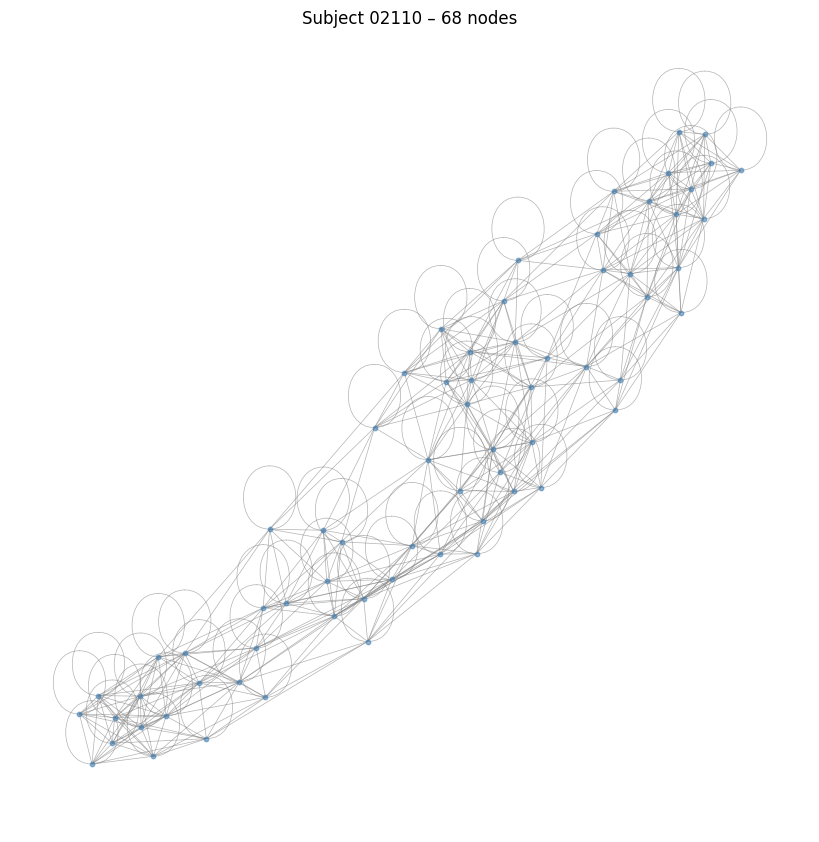

In [26]:
#Visualize graph

import matplotlib.pyplot as plt
import networkx as nx
from torch_geometric.utils import to_networkx


# === Pick the first subject's graph ===
graph = graph_data_list[0]

# === Convert PyG graph to NetworkX for visualization ===
G = to_networkx(graph, to_undirected=True)

# === Optional: layout (slower for large graphs) ===
pos = nx.spring_layout(G, seed=42)  # force-directed layout

# === Plot ===
plt.figure(figsize=(8, 8))
nx.draw(G, pos, node_size=10, node_color='steelblue', edge_color='gray', alpha=0.6, width=0.5)

plt.title(f"Subject {graph.subject_id} – {graph.num_nodes} nodes")
plt.axis('off')
plt.show()


In [27]:
#####################  DEVICE CONFIGURATION  #######################

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")

Using device: cuda


In [28]:
#DEFINE MODEL GCNs
import torch
import torch.nn.functional as F
from torch_geometric.nn import GCNConv, global_mean_pool, BatchNorm

class BrainAgeGNN(torch.nn.Module):
    def __init__(self, input_dim=21):  # ← set to 21 features per node
        super(BrainAgeGNN, self).__init__()

        self.conv1 = GCNConv(input_dim, 64)
        self.bn1 = BatchNorm(64)

        self.conv2 = GCNConv(64, 128)
        self.bn2 = BatchNorm(128)

        self.conv3 = GCNConv(128, 128)
        self.bn3 = BatchNorm(128)

        self.fc = torch.nn.Linear(128, 1)
        self.dropout = torch.nn.Dropout(p=0.5)

    def forward(self, data):
        x, edge_index, batch = data.x, data.edge_index, data.batch

        x = F.relu(self.bn1(self.conv1(x, edge_index)))
        x = F.relu(self.bn2(self.conv2(x, edge_index)))
        x_residual = x
        x = F.relu(self.bn3(self.conv3(x, edge_index)))
        x = x + x_residual

        x = global_mean_pool(x, batch)
        x = self.dropout(x)
        x = self.fc(x)

        return x.view(-1)


In [29]:
  #train and eval funcions  
    
from torch.optim import Adam
from torch_geometric.loader import DataLoader  # Usamos el DataLoader de torch_geometric

def train(model, train_loader, optimizer, criterion):
    model.train()
    total_loss = 0
    for data in train_loader:
        data = data.to(device)  # GPU
        optimizer.zero_grad()
        output = model(data).view(-1)
        loss = criterion(output, data.y)
        loss.backward()
        optimizer.step()
        total_loss += loss.item()
    return total_loss / len(train_loader)


def evaluate(model, test_loader, criterion):
    model.eval()
    total_loss = 0
    with torch.no_grad():
        for data in test_loader:
            data = data.to(device)  # GPU
            output = model(data).view(-1)
            loss = criterion(output, data.y)
            total_loss += loss.item()
    return total_loss / len(test_loader)


In [30]:
#Training

import matplotlib.pyplot as plt
from sklearn.model_selection import StratifiedKFold
import numpy as np
import pandas as pd

# Training settings
epochs = 300
patience = 40
k = 7  # Number of folds
batch_size = 6

# === Initialize loss and tracking ===
all_train_losses = []
all_test_losses = []
all_early_stopping_epochs = []

# === Extract subject IDs from graph list ===
graph_subject_ids = [data.subject_id for data in graph_data_list]

# === Get matching ages in the same order ===
ages = np.array([age_dict[subj_id] for subj_id in graph_subject_ids])

# === Create age bins for stratification ===
age_bins = pd.qcut(ages, q=5, labels=False)  # 5 quantiles


In [31]:
# Final check
print("Total subjects:", len(graph_data_list))
print("Total age bins:", len(age_bins))

from sklearn.model_selection import StratifiedKFold
from torch.optim import AdamW
from torch.optim.lr_scheduler import StepLR
import torch
import numpy as np
from torch_geometric.loader import DataLoader



Total subjects: 59
Total age bins: 59


In [32]:
# Stratified split by age bins
skf = StratifiedKFold(n_splits=k, shuffle=True, random_state=42)
repeats_per_fold = 10


In [33]:
# === Build age vector and age bins ===
graph_subject_ids = [data.subject_id for data in graph_data_list]
ages = np.array([age_dict[subj_id] for subj_id in graph_subject_ids])
age_bins = pd.qcut(ages, q=5, labels=False)

for fold, (train_idx, test_idx) in enumerate(skf.split(graph_data_list, age_bins)):
    print(f'\n--- Fold {fold+1}/{k} ---')

    train_data = [graph_data_list[i] for i in train_idx]
    test_data = [graph_data_list[i] for i in test_idx]

    fold_train_losses = []
    fold_test_losses = []

    for repeat in range(repeats_per_fold):
        print(f'  > Repeat {repeat+1}/{repeats_per_fold}')

        early_stop_epoch = None
        seed_everything(42 + repeat)

        train_loader = DataLoader(train_data, batch_size=batch_size, shuffle=True)
        test_loader = DataLoader(test_data, batch_size=batch_size, shuffle=False)

        model = BrainAgeGNN(input_dim=21).to(device)

        optimizer = AdamW(model.parameters(), lr=0.002, weight_decay=1e-4)
        scheduler = StepLR(optimizer, step_size=20, gamma=0.5)
        criterion = torch.nn.SmoothL1Loss(beta=1)

        best_loss = float('inf')
        patience_counter = 0

        train_losses = []
        test_losses = []

        for epoch in range(epochs):
            train_loss = train(model, train_loader, optimizer, criterion)
            test_loss = evaluate(model, test_loader, criterion)

            train_losses.append(train_loss)
            test_losses.append(test_loss)

            if test_loss < best_loss:
                best_loss = test_loss
                patience_counter = 0
                torch.save(model.state_dict(), f"column_md_model_fold_{fold+1}_rep_{repeat+1}_ref.pt")
            else:
                patience_counter += 1
                if patience_counter >= patience:
                    early_stop_epoch = epoch + 1
                    print(f"    Early stopping triggered at epoch {early_stop_epoch}.")
                    break

            scheduler.step()

        if early_stop_epoch is None:
            early_stop_epoch = epochs

        all_early_stopping_epochs.append((fold + 1, repeat + 1, early_stop_epoch))

        fold_train_losses.append(train_losses)
        fold_test_losses.append(test_losses)

    all_train_losses.append(fold_train_losses)
    all_test_losses.append(fold_test_losses)



--- Fold 1/7 ---
  > Repeat 1/10
    Early stopping triggered at epoch 117.
  > Repeat 2/10
    Early stopping triggered at epoch 85.
  > Repeat 3/10
    Early stopping triggered at epoch 110.
  > Repeat 4/10
    Early stopping triggered at epoch 106.
  > Repeat 5/10
    Early stopping triggered at epoch 95.
  > Repeat 6/10
    Early stopping triggered at epoch 115.
  > Repeat 7/10
    Early stopping triggered at epoch 96.
  > Repeat 8/10
    Early stopping triggered at epoch 100.
  > Repeat 9/10
    Early stopping triggered at epoch 85.
  > Repeat 10/10
    Early stopping triggered at epoch 127.

--- Fold 2/7 ---
  > Repeat 1/10
    Early stopping triggered at epoch 102.
  > Repeat 2/10
    Early stopping triggered at epoch 85.
  > Repeat 3/10
    Early stopping triggered at epoch 96.
  > Repeat 4/10
    Early stopping triggered at epoch 106.
  > Repeat 5/10
    Early stopping triggered at epoch 60.
  > Repeat 6/10
    Early stopping triggered at epoch 110.
  > Repeat 7/10
    Early 

C:\Users\22679\AppData\Local\Temp\ipykernel_17192\2581121043.py:19: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()


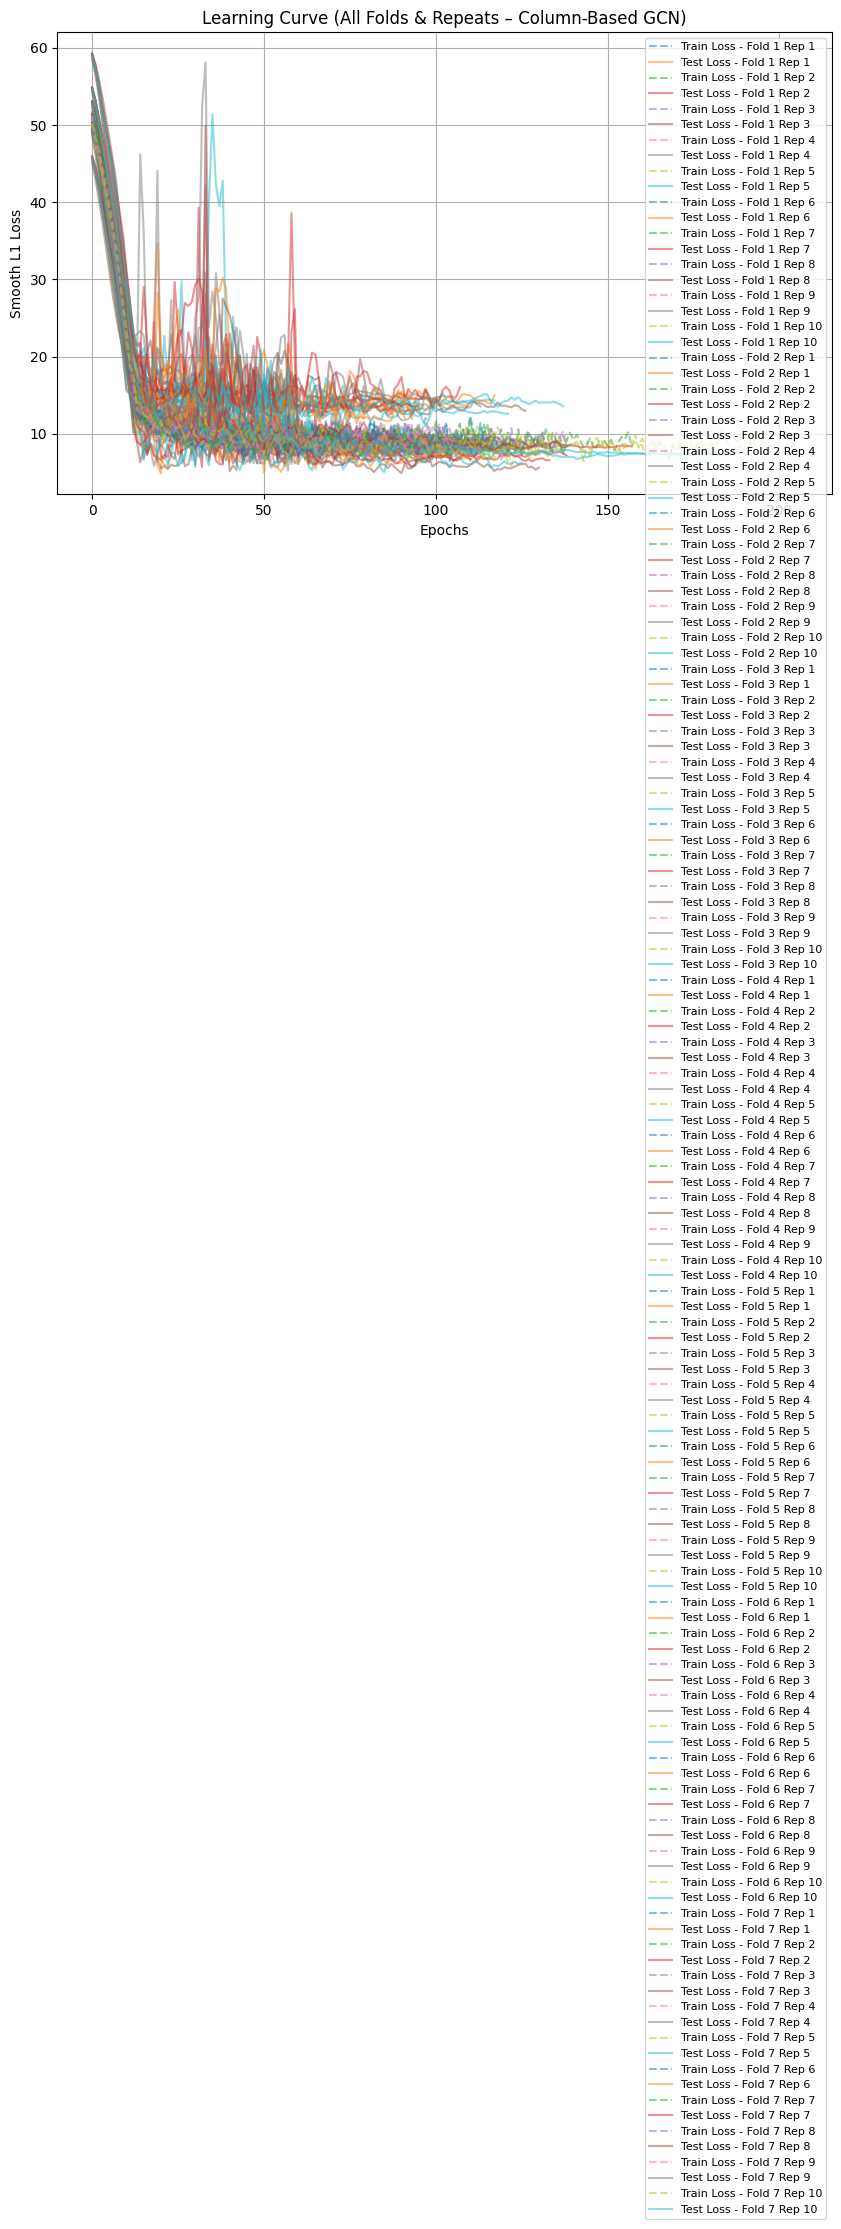

In [34]:
##################  LEARNING CURVE (ALL FOLDS + REPEATS)  ##################

import matplotlib.pyplot as plt
import numpy as np

plt.figure(figsize=(10, 6))

# Plot learning curves for each fold and repetition
for fold in range(k):
    for rep in range(repeats_per_fold):
        plt.plot(all_train_losses[fold][rep], label=f'Train Loss - Fold {fold+1} Rep {rep+1}', linestyle='dashed', alpha=0.5)
        plt.plot(all_test_losses[fold][rep], label=f'Test Loss - Fold {fold+1} Rep {rep+1}', alpha=0.5)

plt.xlabel("Epochs")
plt.ylabel("Smooth L1 Loss")
plt.title("Learning Curve (All Folds & Repeats – Column-Based GCN)")
plt.legend(loc="upper right", fontsize=8)
plt.grid(True)
plt.tight_layout()
plt.show()


In [35]:
#######################  LEARNING CURVE (MEAN ± STD)  ########################
# Compute mean and std per epoch across all folds and repetitions
avg_train = []
avg_test = []

for epoch in range(epochs):
    epoch_train = []
    epoch_test = []
    for fold in range(k):
        for rep in range(repeats_per_fold):
            if epoch < len(all_train_losses[fold][rep]):
                epoch_train.append(all_train_losses[fold][rep][epoch])
                epoch_test.append(all_test_losses[fold][rep][epoch])
    avg_train.append((np.mean(epoch_train), np.std(epoch_train)))
    avg_test.append((np.mean(epoch_test), np.std(epoch_test)))



d:\Anaconda\install\envs\GNN\Lib\site-packages\numpy\core\fromnumeric.py:3504: RuntimeWarning: Mean of empty slice.
  return _methods._mean(a, axis=axis, dtype=dtype,
d:\Anaconda\install\envs\GNN\Lib\site-packages\numpy\core\_methods.py:129: RuntimeWarning: invalid value encountered in scalar divide
  ret = ret.dtype.type(ret / rcount)
d:\Anaconda\install\envs\GNN\Lib\site-packages\numpy\core\_methods.py:206: RuntimeWarning: Degrees of freedom <= 0 for slice
  ret = _var(a, axis=axis, dtype=dtype, out=out, ddof=ddof,
d:\Anaconda\install\envs\GNN\Lib\site-packages\numpy\core\_methods.py:163: RuntimeWarning: invalid value encountered in divide
  arrmean = um.true_divide(arrmean, div, out=arrmean,
d:\Anaconda\install\envs\GNN\Lib\site-packages\numpy\core\_methods.py:198: RuntimeWarning: invalid value encountered in scalar divide
  ret = ret.dtype.type(ret / rcount)


In [36]:
# Unpack values
train_mean, train_std = zip(*avg_train)
test_mean, test_std = zip(*avg_test)

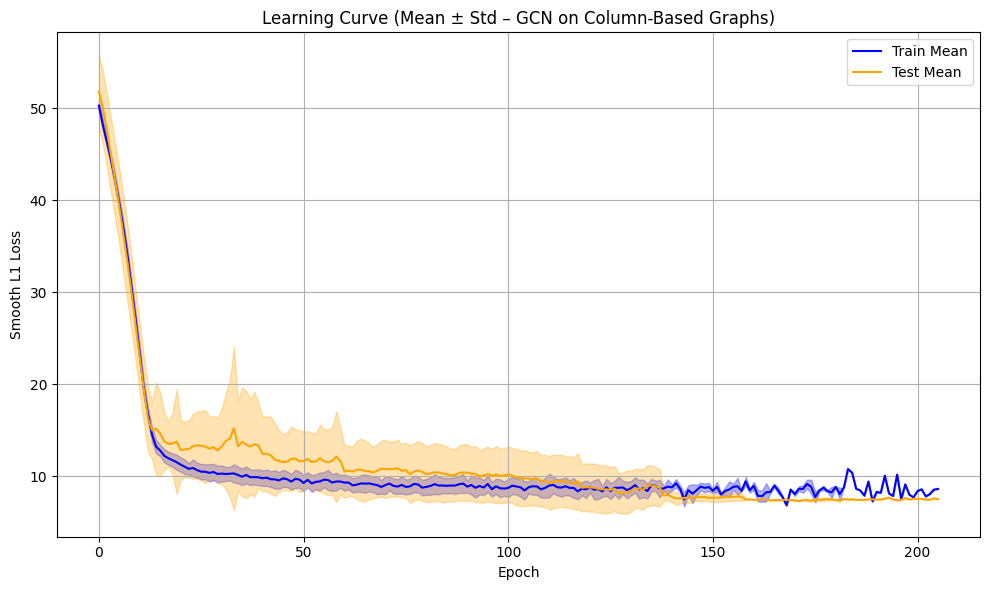

In [37]:
# Plot mean ± std
plt.figure(figsize=(10, 6))

plt.plot(train_mean, label="Train Mean", color="blue")
plt.fill_between(range(epochs), np.array(train_mean) - np.array(train_std),
                 np.array(train_mean) + np.array(train_std), color="blue", alpha=0.3)

plt.plot(test_mean, label="Test Mean", color="orange")
plt.fill_between(range(epochs), np.array(test_mean) - np.array(test_std),
                 np.array(test_mean) + np.array(test_std), color="orange", alpha=0.3)

plt.xlabel("Epoch")
plt.ylabel("Smooth L1 Loss")
plt.title("Learning Curve (Mean ± Std – GCN on Column-Based Graphs)")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()


In [38]:
##################  PREDICTION & METRIC ANALYSIS (COLUMN-BASED GRAPHS)  ##################

from sklearn.metrics import mean_absolute_error, r2_score, mean_squared_error
import matplotlib.pyplot as plt


# === Initialize storage ===
fold_mae_list = []
fold_r2_list = []
fold_rmse_list = []

all_subject_ids = []
all_y_true = []
all_y_pred = []

# Create a new folder to save the y_true, y_pred, and subject_ids in each fold and repeat
if not os.path.exists("column_md_results"):
    os.makedirs("column_md_results")

for fold, (train_idx, test_idx) in enumerate(skf.split(graph_data_list, age_bins)):
    print(f'\n--- Evaluating Fold {fold+1}/{k} ---')

    test_data = [graph_data_list[i] for i in test_idx]
    test_loader = DataLoader(test_data, batch_size=batch_size, shuffle=False)
    train_data = [graph_data_list[i] for i in train_idx]
    train_loader = DataLoader(train_data, batch_size=batch_size, shuffle=False)

    repeat_maes = []
    repeat_r2s = []
    repeat_rmses = []

    for rep in range(repeats_per_fold):
        print(f"  > Repeat {rep+1}/{repeats_per_fold}")

        model = BrainAgeGNN(input_dim=21).to(device)  # ← Your model

        model.load_state_dict(torch.load(f"column_md_model_fold_{fold+1}_rep_{rep+1}_ref.pt"))  # Load saved model
        model.eval()

        subject_id_repeat = []
        y_true_repeat = []
        y_pred_repeat = []

        subject_id_repeat_train = []
        y_true_repeat_train = []
        y_pred_repeat_train = []

        with torch.no_grad():
            for data in test_loader:
                data = data.to(device)
                output = model(data).view(-1)
                subject_id_repeat.extend(data.subject_id)
                y_pred_repeat.extend(output.cpu().tolist())
                y_true_repeat.extend(data.y.cpu().tolist())
            # Save predictions and true values to files
            test_results_df = pd.DataFrame({
                'subject_id': subject_id_repeat,
                'y_true': y_true_repeat,
                'y_pred': y_pred_repeat
            })
            test_results_df.to_csv(f"column_md_results/fold_{fold+1}_rep_{rep+1}_test_results_ref.csv", index=False)

            for data in train_loader:
                data = data.to(device)
                output = model(data).view(-1)
                subject_id_repeat_train.extend(data.subject_id)
                y_pred_repeat_train.extend(output.cpu().tolist())
                y_true_repeat_train.extend(data.y.cpu().tolist())
            # Save predictions and true values for training data
            train_results_df = pd.DataFrame({
                'subject_id': subject_id_repeat_train,
                'y_true': y_true_repeat_train,
                'y_pred': y_pred_repeat_train
            })
            train_results_df.to_csv(f"column_md_results/fold_{fold+1}_rep_{rep+1}_train_results_ref.csv", index=False)

        # Compute metrics
        mae = mean_absolute_error(y_true_repeat, y_pred_repeat)
        r2 = r2_score(y_true_repeat, y_pred_repeat)
        rmse = np.sqrt(mean_squared_error(y_true_repeat, y_pred_repeat))

        repeat_maes.append(mae)
        repeat_r2s.append(r2)
        repeat_rmses.append(rmse)

        all_y_true.extend(y_true_repeat)
        all_y_pred.extend(y_pred_repeat)
        all_subject_ids.extend(subject_id_repeat)

    fold_mae_list.append(repeat_maes)
    fold_r2_list.append(repeat_r2s)
    fold_rmse_list.append(repeat_rmses)

    print(f">> Fold {fold+1} | MAE: {np.mean(repeat_maes):.2f} ± {np.std(repeat_maes):.2f} | "
          f"R²: {np.mean(repeat_r2s):.2f} ± {np.std(repeat_r2s):.2f} | "
          f"RMSE: {np.mean(repeat_rmses):.2f} ± {np.std(repeat_rmses):.2f}")




--- Evaluating Fold 1/7 ---
  > Repeat 1/10
  > Repeat 2/10


C:\Users\22679\AppData\Local\Temp\ipykernel_17192\4061710541.py:37: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model.load_state_dict(torch.load(f"column_md_model_fold_{fo

  > Repeat 3/10
  > Repeat 4/10


C:\Users\22679\AppData\Local\Temp\ipykernel_17192\4061710541.py:37: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model.load_state_dict(torch.load(f"column_md_model_fold_{fo

  > Repeat 5/10
  > Repeat 6/10


...

  > Repeat 7/10
  > Repeat 8/10


C:\Users\22679\AppData\Local\Temp\ipykernel_17192\4061710541.py:37: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model.load_state_dict(torch.load(f"column_md_model_fold_{fo

  > Repeat 9/10
  > Repeat 10/10


C:\Users\22679\AppData\Local\Temp\ipykernel_17192\4061710541.py:37: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model.load_state_dict(torch.load(f"column_md_model_fold_{fo

>> Fold 7 | MAE: 9.74 ± 1.04 | R²: 0.34 ± 0.17 | RMSE: 12.76 ± 1.58


In [39]:
# === Final aggregate results ===
all_maes = np.array(fold_mae_list).flatten()
all_r2s = np.array(fold_r2_list).flatten()
all_rmses = np.array(fold_rmse_list).flatten()

print("\n================== FINAL METRICS (COLUMN-BASED GCN) ==================")
print(f"Global MAE:  {np.mean(all_maes):.2f} ± {np.std(all_maes):.2f}")
print(f"Global R²:   {np.mean(all_r2s):.2f} ± {np.std(all_r2s):.2f}")
print(f"Global RMSE: {np.mean(all_rmses):.2f} ± {np.std(all_rmses):.2f}")
print("=======================================================================")



================== FINAL METRICS (COLUMN-BASED GCN) ==================
Global MAE:  9.80 ± 2.74
Global R²:   0.13 ± 0.36
Global RMSE: 12.86 ± 3.36


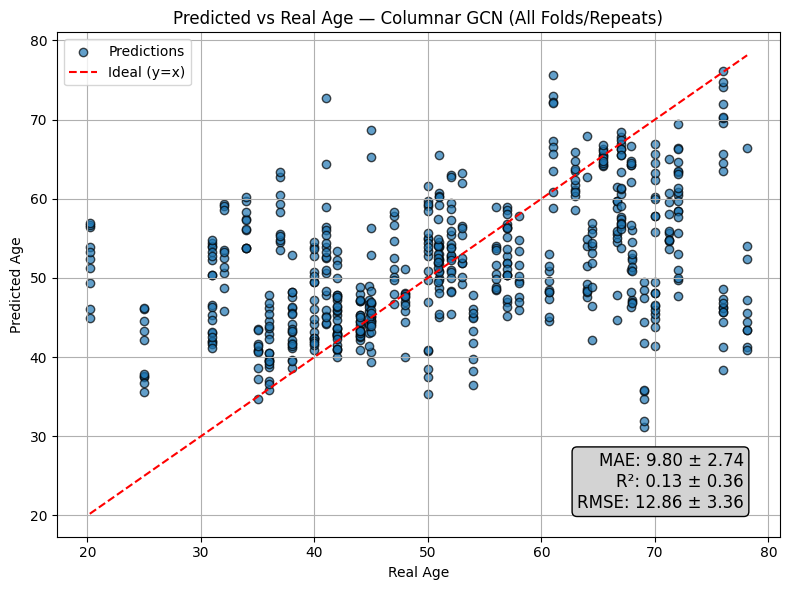

In [40]:
######################  PLOT TRUE VS PREDICTED AGES (COLUMN-BASED)  ######################

import matplotlib.pyplot as plt
import numpy as np

plt.figure(figsize=(8, 6))

# Scatter plot of true vs predicted ages
plt.scatter(all_y_true, all_y_pred, alpha=0.7, edgecolors='k', label="Predictions")


# Diagonal (ideal prediction)
min_val = min(min(all_y_true), min(all_y_pred))
max_val = max(max(all_y_true), max(all_y_pred))
margin = (max_val - min_val) * 0.05
plt.plot([min_val, max_val], [min_val, max_val], color="red", linestyle="dashed", label="Ideal (y=x)")
plt.xlim(min_val - margin, max_val + margin)
plt.ylim(min_val - margin, max_val + margin)


# Metrics text box with MAE, R² and RMSE
textstr = (f"MAE: {np.mean(all_maes):.2f} ± {np.std(all_maes):.2f}\n"
           f"R²: {np.mean(all_r2s):.2f} ± {np.std(all_r2s):.2f}\n"
           f"RMSE: {np.mean(all_rmses):.2f} ± {np.std(all_rmses):.2f}")

plt.text(0.95, 0.05, textstr, transform=plt.gca().transAxes,
         fontsize=12, verticalalignment='bottom', horizontalalignment='right',
         bbox=dict(boxstyle="round,pad=0.3", edgecolor="black", facecolor="lightgray"))

# Labels and style
plt.xlabel("Real Age")
plt.ylabel("Predicted Age")
plt.title("Predicted vs Real Age — Columnar GCN (All Folds/Repeats)")
plt.legend(loc="upper left")
plt.grid(True)
plt.tight_layout()
plt.show()



In [41]:
# Save all_y_true and all_y_pred to CSV
import pandas as pd
# Create a DataFrame from the true and predicted values
# For each subject, there're 7 folds and 10 repeats, so we can flatten the lists and match them
# all_y_true = 67 subjects * 10 repeats * 7 folds = 4690 values
# all_y_pred = 67 subjects * 10 repeats * 7 folds = 4690 values
# Flatten subject IDs if they are lists of lists
def flatten(l):
    return [item for sublist in l for item in sublist] if isinstance(l[0], list) else l

flat_subject_ids = flatten(all_subject_ids)

# Print the length of flat_subject_ids
print(f"Total subjects in flattened list: {len(flat_subject_ids)}")

df_results = pd.DataFrame({
    'subject_id': flat_subject_ids,
    'y_true': all_y_true,
    'y_pred': all_y_pred
})
# Save the mean and std of the predicted ages for each subject
df_results_mean_std = df_results.groupby('subject_id').agg(
    y_true_mean=('y_true', 'mean'),
    y_true_std=('y_true', 'std'),
    y_pred_mean=('y_pred', 'mean'),
    y_pred_std=('y_pred', 'std')
).reset_index()
# Save to CSV
df_results_mean_std.to_csv("column_based_gcn_results_ref.csv", index=False)

Total subjects in flattened list: 590


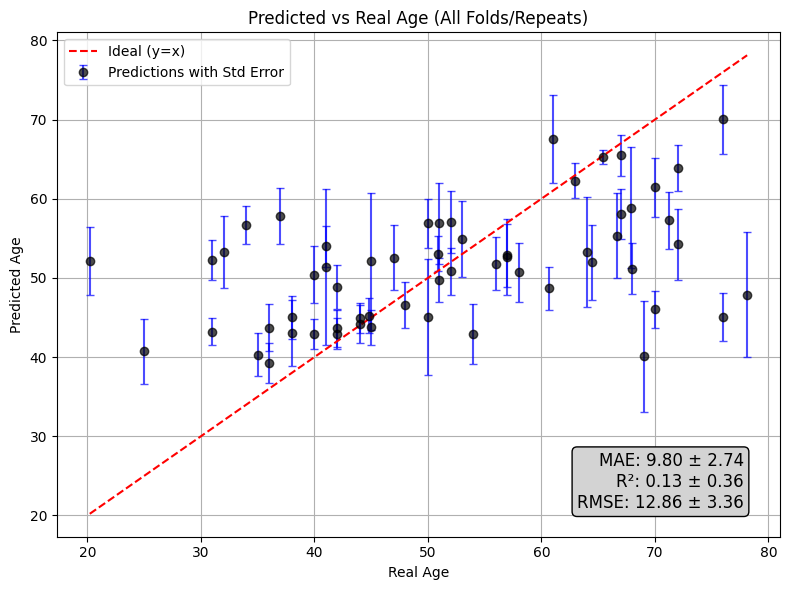

In [42]:
# Plot y_true vs y_pred with error bar being the std of y_pred for each subject
plt.figure(figsize=(8, 6))
plt.errorbar(df_results_mean_std['y_true_mean'], df_results_mean_std['y_pred_mean'],
             yerr=df_results_mean_std['y_pred_std'], fmt='o', alpha=0.7,
             label='Predictions with Std Error', color='black', ecolor='blue',
                capsize=3)
# Diagonal (ideal prediction)
plt.plot([min_val, max_val], [min_val, max_val], color="red", linestyle="dashed", label="Ideal (y=x)")
# Metrics text box with MAE, R² and RMSE
textstr = (f"MAE: {np.mean(all_maes):.2f} ± {np.std(all_maes):.2f}\n"
           f"R²: {np.mean(all_r2s):.2f} ± {np.std(all_r2s):.2f}\n"
           f"RMSE: {np.mean(all_rmses):.2f} ± {np.std(all_rmses):.2f}")

plt.text(0.95, 0.05, textstr, transform=plt.gca().transAxes,
         fontsize=12, verticalalignment='bottom', horizontalalignment='right',
         bbox=dict(boxstyle="round,pad=0.3", edgecolor="black", facecolor="lightgray"))

# Labels and style
plt.xlabel("Real Age")
plt.ylabel("Predicted Age")
plt.title("Predicted vs Real Age (All Folds/Repeats)")
plt.legend(loc="upper left")
plt.grid(True)
plt.tight_layout()
plt.show()

In [43]:
############################################

# FINAL MODEL TRAINING ON HEALTHY + FAMILIAL

############################################

print("\n=== Training Final Model on All Healthy + Familial Subjects ===")

from torch_geometric.loader import DataLoader


# === Create DataLoader with all filtered subjects ===
final_train_loader = DataLoader(graph_data_list, batch_size=6, shuffle=True)


# === Initialize model ===
final_model = BrainAgeGNN(input_dim=21).to(device)


# === Optimizer and learning rate scheduler ===
optimizer = torch.optim.AdamW(final_model.parameters(), lr=0.002, weight_decay=1e-4)
scheduler = torch.optim.lr_scheduler.StepLR(optimizer, step_size=20, gamma=0.5)


# === Loss function ===
criterion = torch.nn.SmoothL1Loss(beta=1)




=== Training Final Model on All Healthy + Familial Subjects ===


In [44]:
# === Train for fixed number of epochs (no early stopping) ===
epochs = 100

for epoch in range(epochs):
    final_model.train()
    total_loss = 0

    for data in final_train_loader:
        data = data.to(device)
        optimizer.zero_grad()
        output = final_model(data).view(-1)
        loss = criterion(output, data.y)
        loss.backward()
        optimizer.step()
        total_loss += loss.item()

    avg_loss = total_loss / len(final_train_loader)
    print(f"Epoch {epoch+1:03d} | Loss: {avg_loss:.4f}")

    scheduler.step()



Epoch 001 | Loss: 50.6450
Epoch 002 | Loss: 48.8361
Epoch 003 | Loss: 46.5114
Epoch 004 | Loss: 43.9865
Epoch 005 | Loss: 41.6136
Epoch 006 | Loss: 38.4861
Epoch 007 | Loss: 35.1451
Epoch 008 | Loss: 31.1859
Epoch 009 | Loss: 27.5673
Epoch 010 | Loss: 23.1082
Epoch 011 | Loss: 19.2804
Epoch 012 | Loss: 15.8580
Epoch 013 | Loss: 13.8447
Epoch 014 | Loss: 12.2720
Epoch 015 | Loss: 11.5005
Epoch 016 | Loss: 12.5134
Epoch 017 | Loss: 11.8045
Epoch 018 | Loss: 11.8937
Epoch 019 | Loss: 11.8867
Epoch 020 | Loss: 11.1226
Epoch 021 | Loss: 10.7197
Epoch 022 | Loss: 10.2057
Epoch 023 | Loss: 10.8034
Epoch 024 | Loss: 10.1255
Epoch 025 | Loss: 11.1814
Epoch 026 | Loss: 11.0562
Epoch 027 | Loss: 9.8689
Epoch 028 | Loss: 9.4247
Epoch 029 | Loss: 10.3456
Epoch 030 | Loss: 11.1838
Epoch 031 | Loss: 9.4759
Epoch 032 | Loss: 10.3656
Epoch 033 | Loss: 10.0756
Epoch 034 | Loss: 9.3508
Epoch 035 | Loss: 9.9276
Epoch 036 | Loss: 9.6829
Epoch 037 | Loss: 10.3811
Epoch 038 | Loss: 10.4861
Epoch 039 | Loss: 

In [45]:
# === Save final model ===
torch.save(final_model.state_dict(), "column_md_model_trained_on_all_healthy_ref.pt")
print("\nFinal model saved as 'model_trained_on_all_healthy_ref.pt'")




Final model saved as 'model_trained_on_all_healthy_ref.pt'


In [46]:
# === Notes ===

# We selected 100 epochs for the final model training based on the early stopping

# behavior observed during cross-validation. Most runs converged between 60–90 epochs (mean=86)

# so 100 allows for full convergence without early stopping.

